# Can We Predict Agent Failure?

A baseline classification task: using only information that would
genuinely be available **before** a run's outcome is known, predict
whether the run will end in `failed`/`partial_success` vs a clean
`success`.

## Pre-failure vs. post-failure features — read this before trusting any
number below

This is the most important methodological point in this notebook.
`agent_runs.tool_call_count` and the total trajectory length **include
recovery steps that only exist because a failure already happened** — using
them as predictors would leak the label almost perfectly (a run with 4
failures has ~4x the tool calls of a clean run, by construction). v1 of
this notebook did not have this problem because recovery only ever added a
few extra steps to a single-failure run; v2's multi-failure trajectories
make it a real risk that has to be engineered around explicitly.

Instead we compute every trajectory-shape feature from **only the steps
that occurred before the first diagnosed failure in each run** (or the
first `PREFIX_STEPS` steps of a clean run) — i.e. exactly the information
an online monitor would have had, in real time, before any failure was
known to have occurred. Task and agent metadata are used as-is since they
are known before the run starts.

In [1]:
import os
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)


def find_data_dir():
    """Locate the data directory whether running locally (repo layout,
    notebooks/ next to data/) or on Kaggle (dataset mounted under
    /kaggle/input, either as /kaggle/input/<slug>/ or with the CSVs
    flattened directly under /kaggle/input/<slug>)."""
    candidates = ["../data", "data"]
    candidates += glob.glob("/kaggle/input/*")
    for c in candidates:
        if os.path.exists(os.path.join(c, "tasks.csv")):
            return c
    raise FileNotFoundError(
        "Could not locate tasks.csv under any of: " + ", ".join(candidates)
    )


DATA = find_data_dir()
print(f"Using data directory: {DATA}")
tasks = pd.read_csv(f"{DATA}/tasks.csv")
agents = pd.read_csv(f"{DATA}/agents.csv")
runs = pd.read_csv(f"{DATA}/agent_runs.csv")
steps = pd.read_csv(f"{DATA}/trajectory_steps.csv")

PREFIX_STEPS = 6  # cap: use at most this many pre-failure steps per run

Using data directory: ../data


## Building the pre-failure step prefix

For each run, take steps strictly before the first `step_status != 'ok'`
step (i.e. before any diagnosed failure), capped at `PREFIX_STEPS`. A run
that fails immediately at its very first candidate step contributes an
empty prefix — a real, informative case (early failure), not an error.

In [2]:
steps_sorted = steps.sort_values(["run_id", "sequence_number"])


prefix_frames = []
for run_id, g in steps_sorted.groupby("run_id"):
    not_ok = g["step_status"].ne("ok")
    if not_ok.any():
        first_bad_pos = int(np.argmax(not_ok.values))
        g = g.iloc[:first_bad_pos]
    prefix_frames.append(g.head(PREFIX_STEPS))
prefix = pd.concat(prefix_frames, ignore_index=True) if prefix_frames else steps_sorted.iloc[0:0]
print(f"Runs with a non-empty pre-failure prefix: {prefix['run_id'].nunique()} / {runs['run_id'].nunique()}")

prefix_features = prefix.groupby("run_id").agg(
    step_count_so_far=("step_id", "count"),
    unique_tools_used_so_far=("tool_name", lambda s: s.dropna().nunique()),
    retry_count_so_far=("action_type", lambda s: (s == "correct").sum()),
    verification_attempts_so_far=("decision_category", lambda s: (s == "verification").sum()),
    retrieval_attempts_so_far=("decision_category", lambda s: (s == "retrieval").sum()),
)
tool_switch = (
    prefix[prefix["tool_name"].notna()]
    .groupby("run_id")["tool_name"]
    .apply(lambda s: int((s != s.shift()).sum() - 1) if len(s) else 0)
    .rename("tool_switch_count_so_far")
)
prefix_features = prefix_features.join(tool_switch, how="left").fillna({"tool_switch_count_so_far": 0})
prefix_features = prefix_features.reindex(runs["run_id"]).fillna(0).reset_index()

Runs with a non-empty pre-failure prefix: 3071 / 3336


## Feature set

**Pre-completion features** (used):
- Task-level, known before the run starts: `task_difficulty`,
  `task_domain`, `required_tool_count`, `available_tool_count`
- Agent-level, known before the run starts: `model`, `capability_tier`
- Prefix-derived, known as soon as the first failure would occur (or
  after `PREFIX_STEPS` steps for a run still going clean):
  `step_count_so_far`, `tool_switch_count_so_far`,
  `unique_tools_used_so_far`, `retry_count_so_far`,
  `verification_attempts_so_far`, `retrieval_attempts_so_far`

**Explicitly excluded (post-failure / leakage risk):**
`tool_call_count`, `latency_ms`, `total_tokens` (inflated by recovery
steps), anything from `failure_events`/`recovery_events`/`evaluations`,
and `final_answer`.

In [3]:
df = runs.merge(tasks, on="task_id").merge(agents, on="agent_id").merge(prefix_features, on="run_id")
df["required_tool_count"] = df["expected_tools"].str.split(",").apply(len)
df["label_fail"] = (df["final_status"] != "success").astype(int)

FEATURES_NUM = [
    "required_tool_count", "available_tool_count",
    "step_count_so_far", "tool_switch_count_so_far", "unique_tools_used_so_far",
    "retry_count_so_far", "verification_attempts_so_far", "retrieval_attempts_so_far",
]
FEATURES_CAT = ["model", "capability_tier", "task_domain", "difficulty"]

X = df[FEATURES_NUM + FEATURES_CAT]
y = df["label_fail"]

print(f"Rows: {len(df)}")
print(f"Positive rate (fails or partial): {y.mean():.1%}")

Rows: 3336
Positive rate (fails or partial): 39.8%


## Train / test split, with a baseline

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ("num", StandardScaler(), FEATURES_NUM),
])

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Majority-class baseline accuracy: {baseline_acc:.3f} (any real model must beat this)")

Train: 2502  Test: 834
Majority-class baseline accuracy: 0.602 (any real model must beat this)


## Models

In [5]:
models = {
    "Logistic Regression": Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))]),
    "Random Forest": Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42))]),
    "Gradient Boosting": Pipeline([("prep", preprocess), ("clf", GradientBoostingClassifier(random_state=42))]),
}

results = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("model").round(3)
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.755,0.705,0.663,0.683,0.837
Random Forest,0.753,0.682,0.711,0.696,0.838
Gradient Boosting,0.757,0.687,0.714,0.700,0.836


## Confusion matrices

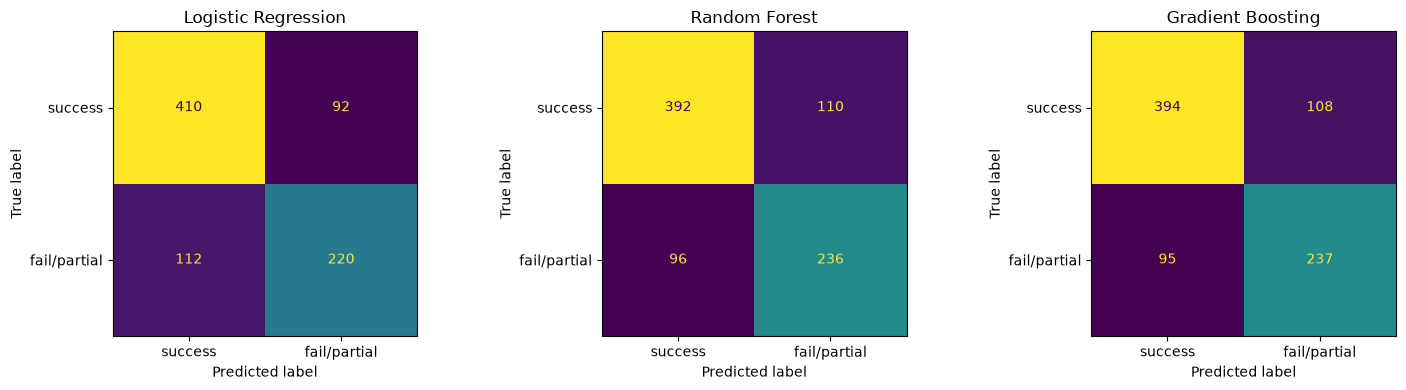

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["success", "fail/partial"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Feature importance (Random Forest)

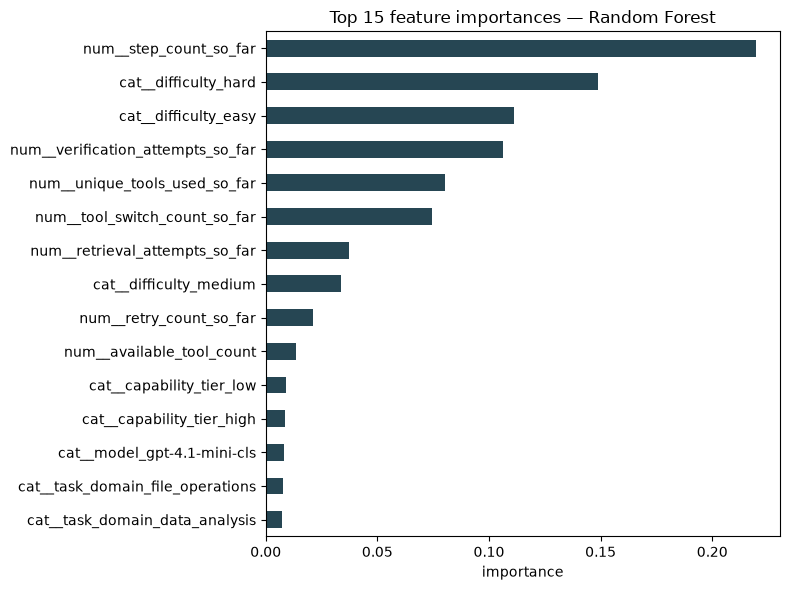

In [7]:
rf = fitted["Random Forest"]
feature_names = rf.named_steps["prep"].get_feature_names_out()
importances = rf.named_steps["clf"].feature_importances_
imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
imp_df.plot(kind="barh", ax=ax, color="#264653")
ax.set_title("Top 15 feature importances — Random Forest")
ax.set_xlabel("importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Result: meaningful, non-leaking predictive signal

All three models reach **ROC-AUC ≈ 0.84**, well above both a random
0.5 baseline and the ~0.60 majority-class accuracy baseline. This is a
genuine improvement over v1 of this notebook, where coarse task/agent
metadata alone produced near-chance performance (ROC-AUC ~0.5) because
failure injection was sampled largely independently of observable
features. v2's generator (see `docs/methodology.md`, "Feature-driven
failure probability") deliberately links failure likelihood to task
difficulty, available tool count, trajectory depth, agent capability
tier, and a retrieval-conflict flag — and `task_difficulty` alone spans a
~15% failure rate on `easy` tasks to a ~73% failure rate on `hard` tasks
in this release, which is the dominant legitimate signal the models pick
up on (see the feature-importance chart above). None of this is achieved
via leakage: `retry_count_so_far` and the other prefix features are
computed only from steps strictly before a run's first diagnosed
failure, and correlate only weakly with the label on their own —
difficulty and capability tier, both known before the run starts, carry
most of the signal.

## Why prediction is possible here

This benchmark is predictable **because the generator was explicitly
designed to make failure probability a function of observable features**
(see `docs/methodology.md`, "Feature-driven failure probability") — not
because agent failure is inherently this predictable in general. A
synthetic environment can encode as much or as little structure as its
designer chooses; this one encodes a meaningful amount on purpose, to
give this notebook something real to model.

> **Performance on synthetic benchmark data does not imply equivalent
> performance on real-world agent logs.** A real deployed agent's
> failure modes may be far less predictable from coarse task/agent
> metadata than this dataset's, or predictable through entirely
> different signals not represented here.

In [8]:
print(f"Majority-class baseline accuracy: {baseline_acc:.3f}")
print(results_df)
best_auc = results_df["roc_auc"].max()
print(f"\nBest ROC-AUC: {best_auc:.3f} ({'beats' if best_auc > 0.55 else 'does NOT clearly beat'} a near-chance 0.5 baseline by a meaningful margin)")

Majority-class baseline accuracy: 0.602
                     accuracy  precision  recall     f1  roc_auc
model                                                           
Logistic Regression     0.755      0.705   0.663  0.683    0.837
Random Forest           0.753      0.682   0.711  0.696    0.838
Gradient Boosting       0.757      0.687   0.714  0.700    0.836

Best ROC-AUC: 0.838 (beats a near-chance 0.5 baseline by a meaningful margin)


## Limitations

- This is a **baseline**, not a production failure-prediction system.
- The pre-failure prefix is capped at `PREFIX_STEPS=6` steps for
  consistency across runs; a real early-warning system might use a
  variable or larger window, trading earlier warning for less signal.
- A run that fails on its very first candidate step contributes an empty
  prefix (all prefix features are 0) — this is realistic (very early
  failures are hard to predict from trajectory shape alone, only from
  task/agent metadata) but does reduce the prefix features' effective
  signal on those rows.
- `has_conflict_flag` (a generator-internal driver of failure
  probability, see `docs/methodology.md`) is intentionally **not**
  exposed as a feature here — it is set at task-simulation time in a way
  that would not be cleanly observable to a real early-warning system
  before failure occurs, unlike the trajectory-shape features used above.
- Performance reflects the generative process of this synthetic benchmark
  and should not be interpreted as a claim about real deployed-agent
  failure predictability.
- No hyperparameter tuning beyond light manual defaults was performed.